# Decision Tree — Network Intrusion Detection

Huấn luyện và đánh giá mô hình **Decision Tree** trên tập dữ liệu CICIDS2017.
Decision Tree không yêu cầu feature scaling.

In [1]:
import os
import sys
import time
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier

# Thêm thư mục gốc dự án vào sys.path
sys.path.insert(0, str(Path.cwd()))
sys.path.append(os.path.abspath(".."))

from src.model_training import (
    load_splits,
    evaluate_model,
    plot_confusion_matrix,
    compare_models,
)

In [2]:
# --- STEP 1: Load dữ liệu đã chia sẵn ---
print("=" * 70)
print("STEP 1: Loading pre-split data")
print("=" * 70)

X_train, X_test, y_train, y_test = load_splits()

print(f"Feature columns: {X_train.shape[1]}")
print(f"Train size: {len(X_train):,}  |  Test size: {len(X_test):,}")
print(f"Classes: {sorted(y_train.unique())}")

STEP 1: Loading pre-split data
Loaded splits from disk.
Feature columns: 52
Train size: 2,016,609  |  Test size: 504,153
Classes: ['BENIGN', 'Bot', 'Brute Force', 'DDoS', 'DoS', 'Heartbleed', 'PortScan', 'Web Attack � Brute Force', 'Web Attack � Sql Injection', 'Web Attack � XSS']


In [3]:
# --- STEP 2: Train Decision Tree ---
print("\n" + "=" * 70)
print("STEP 2: Training Decision Tree (max_depth=20)")
print("=" * 70)

t0 = time.time()

dt_model = DecisionTreeClassifier(
    max_depth=20,
    random_state=42,
)

print("Fitting model on training data (no scaling needed)...")
dt_model.fit(X_train, y_train)

train_time = time.time() - t0
print(f"\nTraining completed in {train_time:.2f} seconds")
print(f"Tree depth: {dt_model.get_depth()}")
print(f"Number of leaves: {dt_model.get_n_leaves()}")


STEP 2: Training Decision Tree (max_depth=20)
Fitting model on training data (no scaling needed)...

Training completed in 76.68 seconds
Tree depth: 20
Number of leaves: 1247


In [4]:
# --- STEP 3: Evaluate ---
print("\n" + "=" * 70)
print("STEP 3: Model Evaluation")
print("=" * 70)

y_pred = dt_model.predict(X_test)
y_pred_proba = dt_model.predict_proba(X_test)

dt_results = evaluate_model(
    y_true=y_test,
    y_pred=y_pred,
    model_name="Decision Tree (depth=20)",
    y_pred_proba=y_pred_proba,
    labels=dt_model.classes_.tolist(),
)


STEP 3: Model Evaluation

  Decision Tree (depth=20) — Evaluation Results
                            precision    recall  f1-score   support

                    BENIGN       1.00      1.00      1.00    419012
                       Bot       0.73      0.74      0.74       390
               Brute Force       1.00      1.00      1.00      1830
                      DDoS       1.00      1.00      1.00     25603
                       DoS       1.00      1.00      1.00     38749
                Heartbleed       1.00      0.50      0.67         2
                  PortScan       0.99      0.99      0.99     18139
  Web Attack � Brute Force       0.71      0.77      0.74       294
Web Attack � Sql Injection       1.00      0.25      0.40         4
          Web Attack � XSS       0.39      0.27      0.32       130

                  accuracy                           1.00    504153
                 macro avg       0.88      0.75      0.78    504153
              weighted avg       1.00  


STEP 4: Confusion Matrix


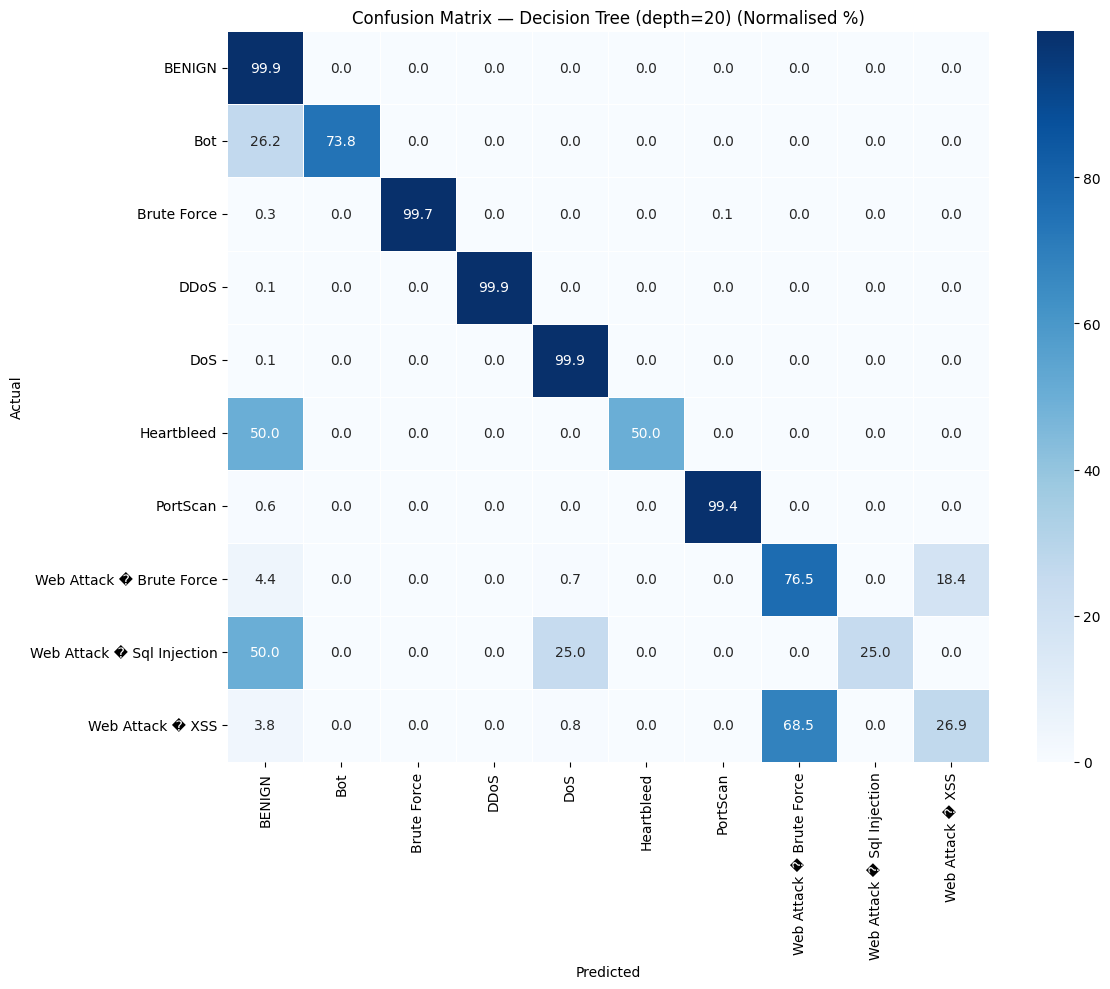

In [5]:
# --- STEP 4: Confusion Matrix ---
print("\n" + "=" * 70)
print("STEP 4: Confusion Matrix")
print("=" * 70)

plot_confusion_matrix(
    y_true=y_test,
    y_pred=y_pred,
    labels=dt_model.classes_.tolist(),
    model_name="Decision Tree (depth=20)",
    normalize=True,
    figsize=(12, 10),
)


STEP 5: Feature Importance (Top 20)
                Feature  Importance
  Bwd Packet Length Std    0.393815
  Fwd Packet Length Max    0.141579
      Subflow Fwd Bytes    0.102997
      Packet Length Std    0.088977
           Flow IAT Std    0.070875
    Average Packet Size    0.070358
       Destination Port    0.041048
 Init_Win_bytes_forward    0.016490
      Total Fwd Packets    0.015036
           Flow IAT Min    0.013325
         PSH Flag Count    0.008626
   min_seg_size_forward    0.004962
           Bwd IAT Mean    0.004230
            Fwd IAT Min    0.003594
Init_Win_bytes_backward    0.003132
          Bwd Packets/s    0.002816
            Bwd IAT Std    0.002227
           Flow IAT Max    0.001966
 Bwd Packet Length Mean    0.001834
     Packet Length Mean    0.001668


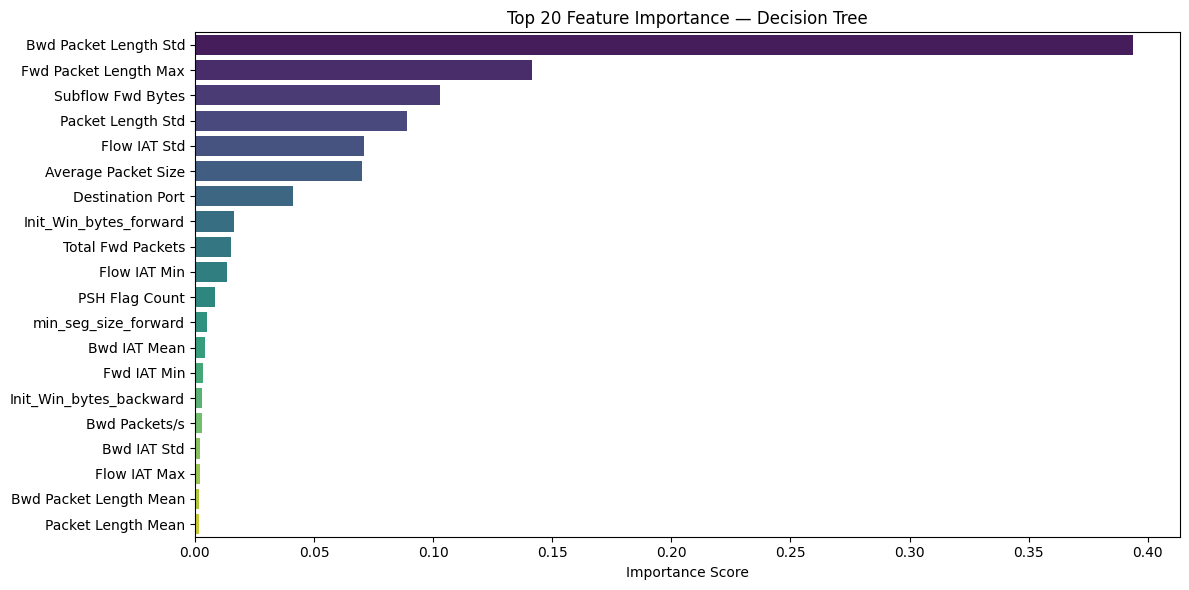

In [6]:
# --- STEP 5: Feature Importance ---
print("\n" + "=" * 70)
print("STEP 5: Feature Importance (Top 20)")
print("=" * 70)

feat_imp = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": dt_model.feature_importances_,
}).sort_values("Importance", ascending=False)

print(feat_imp.head(20).to_string(index=False))

plt.figure(figsize=(12, 6))
sns.barplot(
    data=feat_imp.head(20),
    x="Importance", y="Feature",
    hue="Feature", legend=False,
    palette="viridis",
)
plt.title("Top 20 Feature Importance — Decision Tree")
plt.xlabel("Importance Score")
plt.ylabel("")
plt.tight_layout()
plt.show()

In [7]:
# --- STEP 6: Summary ---
print("\n" + "=" * 70)
print("STEP 6: Summary")
print("=" * 70)

comparison_df = compare_models([dt_results])
print("\nPerformance Metrics:")
print(comparison_df.to_string(index=False))

print(f"\nTraining time : {train_time:.2f}s")
print(f"Test set size : {len(y_test):,}")
print(f"Features      : {X_train.shape[1]}")
print(f"Classes       : {len(dt_model.classes_)}")


STEP 6: Summary

Performance Metrics:
                   Model  Accuracy  Precision (weighted)  Precision (macro)  Recall (weighted)  Recall (macro)  F1 (weighted)  F1 (macro)  Cohen Kappa    MCC  ROC-AUC (weighted)  ROC-AUC (macro)
Decision Tree (depth=20)    0.9983                0.9983             0.8814             0.9983          0.7511         0.9983      0.7842       0.9944 0.9944              0.9988           0.9552

Training time : 76.68s
Test set size : 504,153
Features      : 52
Classes       : 10
